# Location & Fitness — final-solution comparison

Compares algorithms by their **final best solution** (location) and **final
fitness quality**, using `outputs/dim_{d}/results.csv` (from `harvest_results.py`).

Fitness is shown as **precision = f(x) − f_opt** on a **log scale** (the BBOB
standard), so it's comparable across functions and readable across the many
orders of magnitude optimization results span. `f_opt` and the optimum location are pulled from cocoex's internal
`_best_parameter` lookup (not part of the public API, but used
internally by the pymoo library too).

**Prerequisites:** `results.csv` exists per dimension, and cocoex is importable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import cocoex

# ---- knobs ----
DIM = 2
F, I = 23, 1          # which BBOB function / instance to focus single-problem plots on
OUTPUTS_DIR = "outputs"

# algorithms to compare (None = all present in results.csv)
ALGOS = ["OriginalDE","SADE","OriginalSHADE","AugmentedAEO", "GWO_WOA", "OriginalGWO", "OriginalMRFO", "OriginalALO"]

In [2]:
# --- load results.csv for this dimension ---
res = pd.read_csv(f"{OUTPUTS_DIR}/dim_{DIM}/results.csv")
coord_cols = [c for c in res.columns if c.startswith('x')]
print("results:", res.shape, "| coord cols:", coord_cols)

if ALGOS is None:
    ALGOS = sorted(res['algorithm'].unique())
print("algorithms:", len(ALGOS))
res.head()

results: (16800, 7) | coord cols: ['x1', 'x2']
algorithms: 8


,algorithm,problem_id,instance_id,seed,x1,x2,fitness
0,AugmentedAEO,10,1,1,-1.499195,-1.557220,-54.886146
1,AugmentedAEO,10,1,2,-2.250923,-1.394376,-54.669976
2,AugmentedAEO,10,1,3,1.687909,-2.247219,-43.155417
3,AugmentedAEO,10,1,4,1.122099,-2.125025,-46.551155
4,AugmentedAEO,10,1,5,0.184864,-1.922097,-51.265237


In [3]:
# --- get TRUE f_opt and x_opt per (problem_id, instance_id) from cocoex ---
# cocoex doesn't expose the optimum through its public API (no best_value /
# best_parameter attributes on this build). Its INTERNAL _best_parameter
# method - also used internally by the pymoo library - writes x_opt to a
# temp file we can read back; f_opt is then f(x_opt), evaluated on a FRESH
# problem instance so it doesn't count against the real run's evaluation
# budget.
import os

def get_bbob_optimum(function, instance, dim):
    suite_filter = f"function_indices:{function} instance_indices:{instance} dimensions:{dim}"
    suite = cocoex.Suite("bbob", "", suite_filter)
    problem = suite.next_problem()
    tmpfile = '._bbob_problem_best_parameter.txt'
    problem._best_parameter(what="print")
    x_opt = np.loadtxt(tmpfile)
    os.remove(tmpfile)
    f_opt = problem(x_opt)
    return f_opt, x_opt

# build a lookup of true optima for every (function, instance) combination
# present in the results - one cocoex call per combination (cheap: ~120 for
# a full dimension).
optima = {}
for f, i in res[['problem_id', 'instance_id']].drop_duplicates().itertuples(index=False):
    optima[(f, i)] = get_bbob_optimum(f, i, DIM)

f_opt_FI, x_opt_FI = optima[(F, I)]
print(f"F{F}_I{I}: pravi f_opt (cocoex, prek _best_parameter) = {f_opt_FI}")
print("pravi x_opt:", x_opt_FI)


F23_I1: pravi f_opt (cocoex, prek _best_parameter) = 6.87
pravi x_opt: [2.7672 2.1248]


In [4]:
# --- attach precision = fitness - f_opt to the results frame ---
res['f_opt'] = res.apply(lambda r: optima[(r['problem_id'], r['instance_id'])][0], axis=1)
res['precision'] = (res['fitness'] - res['f_opt']).clip(lower=1e-12)
res[['algorithm','problem_id','instance_id','seed','fitness','f_opt','precision']].head()


,algorithm,problem_id,instance_id,seed,fitness,f_opt,precision
0,AugmentedAEO,10,1,1,-54.886146,-54.94,0.053854
1,AugmentedAEO,10,1,2,-54.669976,-54.94,0.270024
2,AugmentedAEO,10,1,3,-43.155417,-54.94,11.784583
3,AugmentedAEO,10,1,4,-46.551155,-54.94,8.388845
4,AugmentedAEO,10,1,5,-51.265237,-54.94,3.674763


## A. Final-precision distribution per algorithm
For one function+instance, each algorithm's final precision across runs (log y).
**Lower = closer to the true optimum.** Box position = quality, spread = run-to-run
consistency. This is the "who actually won, and how reliably" plot.

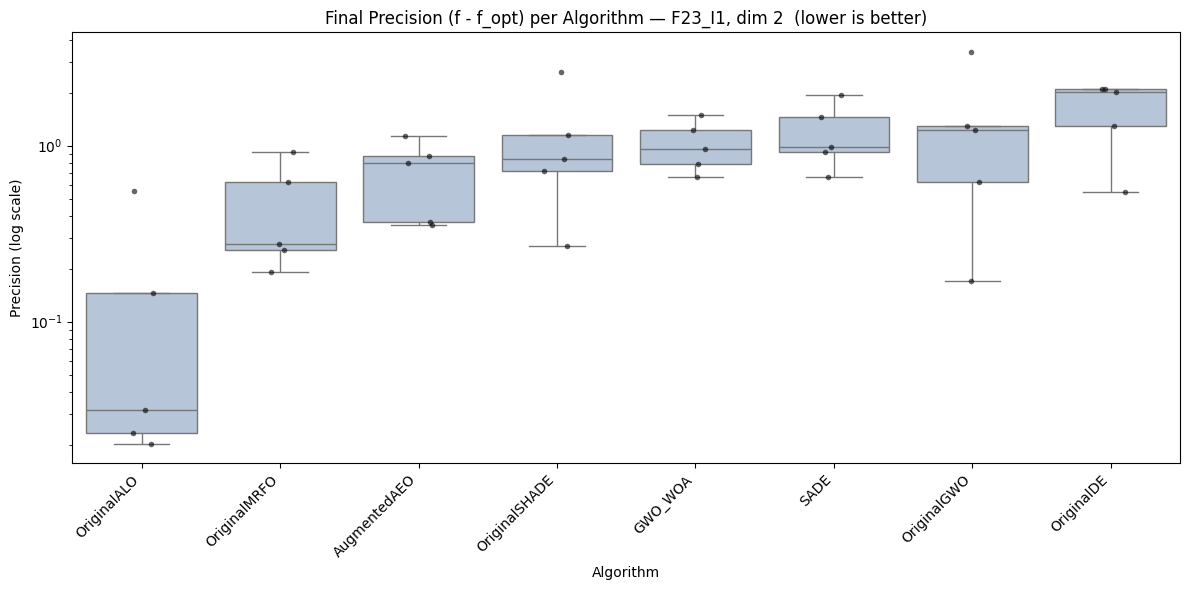

In [5]:
sub = res[(res['problem_id']==F) & (res['instance_id']==I) & (res['algorithm'].isin(ALGOS))]
order = sub.groupby('algorithm')['precision'].median().sort_values().index  # best first

plt.figure(figsize=(12, 6))
sns.boxplot(data=sub, x='algorithm', y='precision', order=order, color='lightsteelblue', showfliers=False)
sns.stripplot(data=sub, x='algorithm', y='precision', order=order, color='black', size=4, alpha=0.6)
plt.yscale('log')
plt.title(f'Final Precision (f - f_opt) per Algorithm — F{F}_I{I}, dim {DIM}  (lower is better)')
plt.xlabel('Algorithm'); plt.ylabel('Precision (log scale)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## B. Pairwise fitness-difference heatmap
Mean absolute difference in **log10 precision** between algorithms across runs
(seed-paired). Using log precision keeps the scale from being dominated by the
worst runs. Low = the two algorithms achieved similar solution quality.

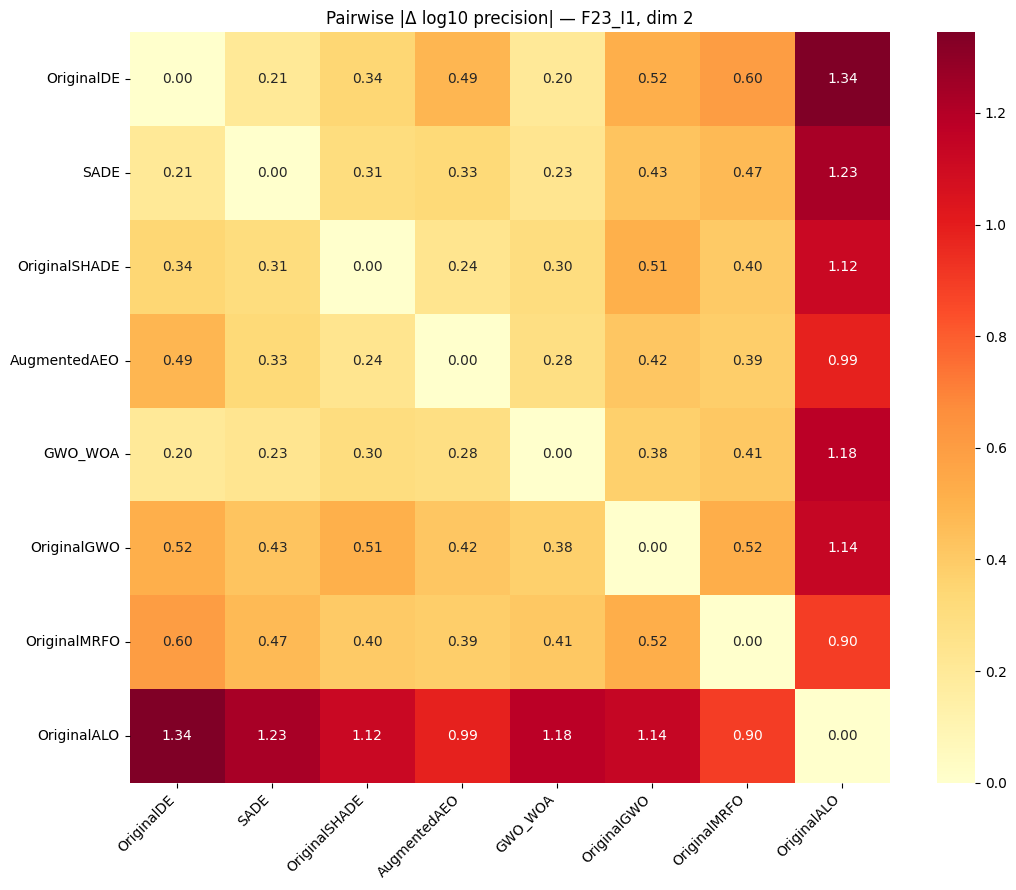

In [6]:
def logprec(alg, seed):
    r = sub[(sub['algorithm']==alg) & (sub['seed']==seed)]
    if r.empty: return None
    return np.log10(r['precision'].iloc[0])

seeds = sorted(sub['seed'].unique())
n = len(ALGOS)
Mf = pd.DataFrame(np.full((n, n), np.nan), index=ALGOS, columns=ALGOS)
for a1, a2 in combinations(ALGOS, 2):
    diffs = []
    for s in seeds:
        l1, l2 = logprec(a1, s), logprec(a2, s)
        if l1 is not None and l2 is not None:
            diffs.append(abs(l1 - l2))
    v = np.mean(diffs) if diffs else np.nan
    Mf.loc[a1, a2] = v; Mf.loc[a2, a1] = v
for a in ALGOS: Mf.loc[a, a] = 0.0

plt.figure(figsize=(11, 9))
sns.heatmap(Mf, annot=(n <= 12), fmt='.2f', cmap='YlOrRd')
plt.title(f'Pairwise |Δ log10 precision| — F{F}_I{I}, dim {DIM}')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## C. Pairwise location-difference heatmap
Mean L2 distance between algorithms' final best points across runs (seed-paired).
Raw coordinate space, so per-instance only. Low = ended up in the same region.

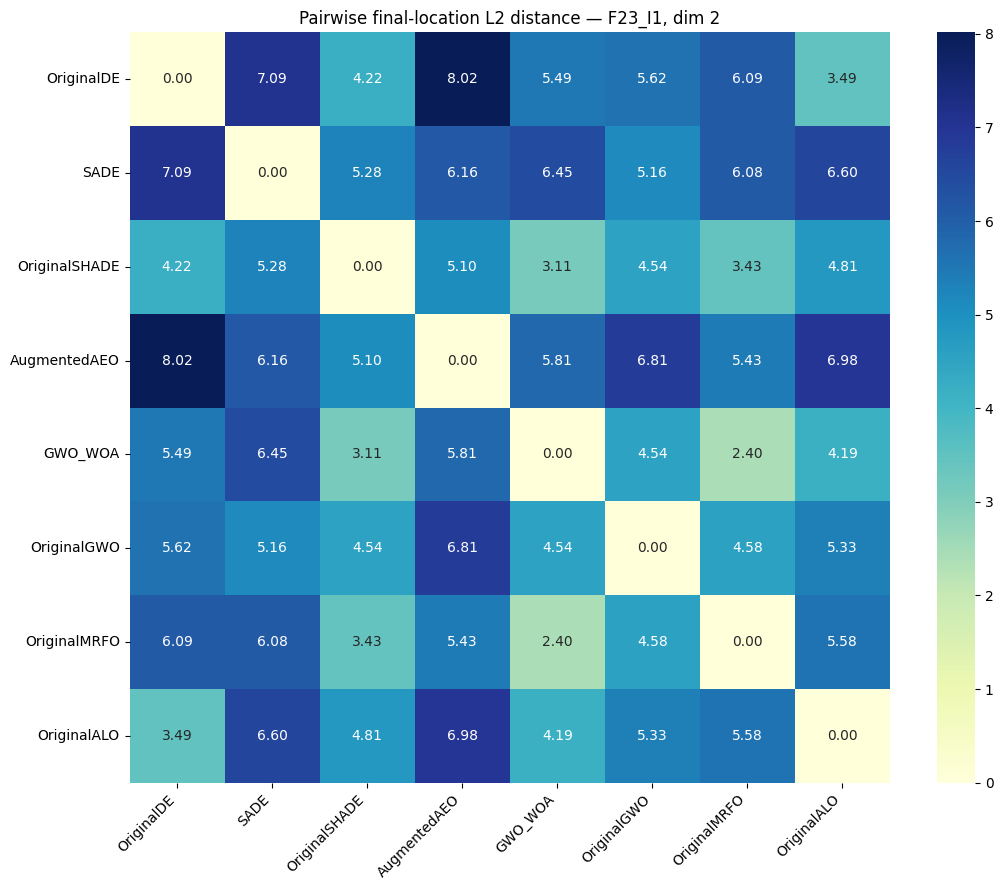

In [7]:
def loc(alg, seed):
    r = sub[(sub['algorithm']==alg) & (sub['seed']==seed)]
    if r.empty: return None
    return r[coord_cols].to_numpy()[0]

Ml = pd.DataFrame(np.full((n, n), np.nan), index=ALGOS, columns=ALGOS)
for a1, a2 in combinations(ALGOS, 2):
    diffs = []
    for s in seeds:
        p1, p2 = loc(a1, s), loc(a2, s)
        if p1 is not None and p2 is not None:
            diffs.append(np.linalg.norm(p1 - p2))
    v = np.mean(diffs) if diffs else np.nan
    Ml.loc[a1, a2] = v; Ml.loc[a2, a1] = v
for a in ALGOS: Ml.loc[a, a] = 0.0

plt.figure(figsize=(11, 9))
sns.heatmap(Ml, annot=(n <= 12), fmt='.2f', cmap='YlGnBu')
plt.title(f'Pairwise final-location L2 distance — F{F}_I{I}, dim {DIM}')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## D. Final-location scatter (dim 2 only)
Every algorithm's final best point in actual 2D search space for this instance,
with the true optimum marked. Only meaningful at dim 2 — you literally see who
converged to the optimum vs got stuck elsewhere. (Cell no-ops if DIM != 2.)

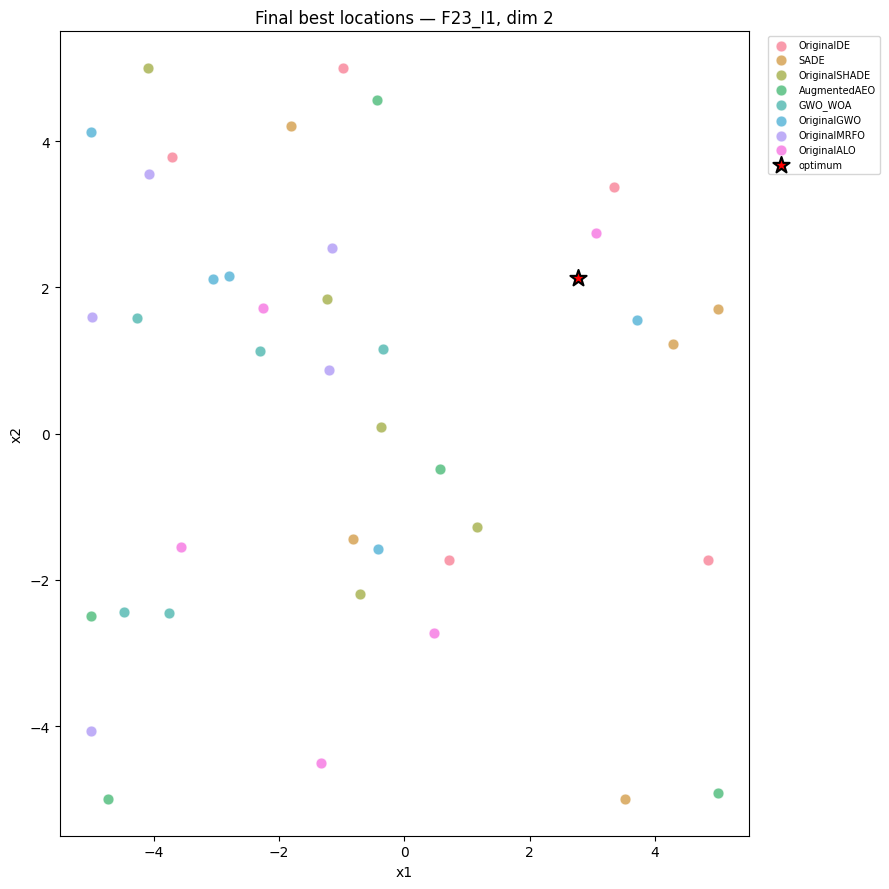

In [8]:
if DIM != 2:
    print(f"Location scatter only meaningful at dim 2 (current DIM={DIM}). Skipping.")
else:
    plt.figure(figsize=(9, 9))
    palette = sns.color_palette('husl', len(ALGOS))
    for alg, color in zip(ALGOS, palette):
        pts = sub[sub['algorithm']==alg][coord_cols].to_numpy()
        plt.scatter(pts[:, 0], pts[:, 1], color=color, s=60, alpha=0.7, label=alg, edgecolors='white', linewidths=0.5)
    if x_opt_FI is not None:
        plt.scatter(x_opt_FI[0], x_opt_FI[1], marker='*', s=150, color='red',
                    edgecolors='black', linewidths=1.5, zorder=5, label='optimum')
    plt.title(f'Final best locations — F{F}_I{I}, dim 2')
    plt.xlabel('x1'); plt.ylabel('x2')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    plt.tight_layout()
    plt.show()

## E. Location difference vs fitness difference
One point per algorithm pair: x = final-location L2 distance, y = |Δ log10 precision|.
The interesting region is **bottom-right**: pairs far apart in space but similar in
fitness — they found *different but equally-good* basins (common on multimodal
functions). Top-left (close in space, different fitness) is rarer and worth a look.

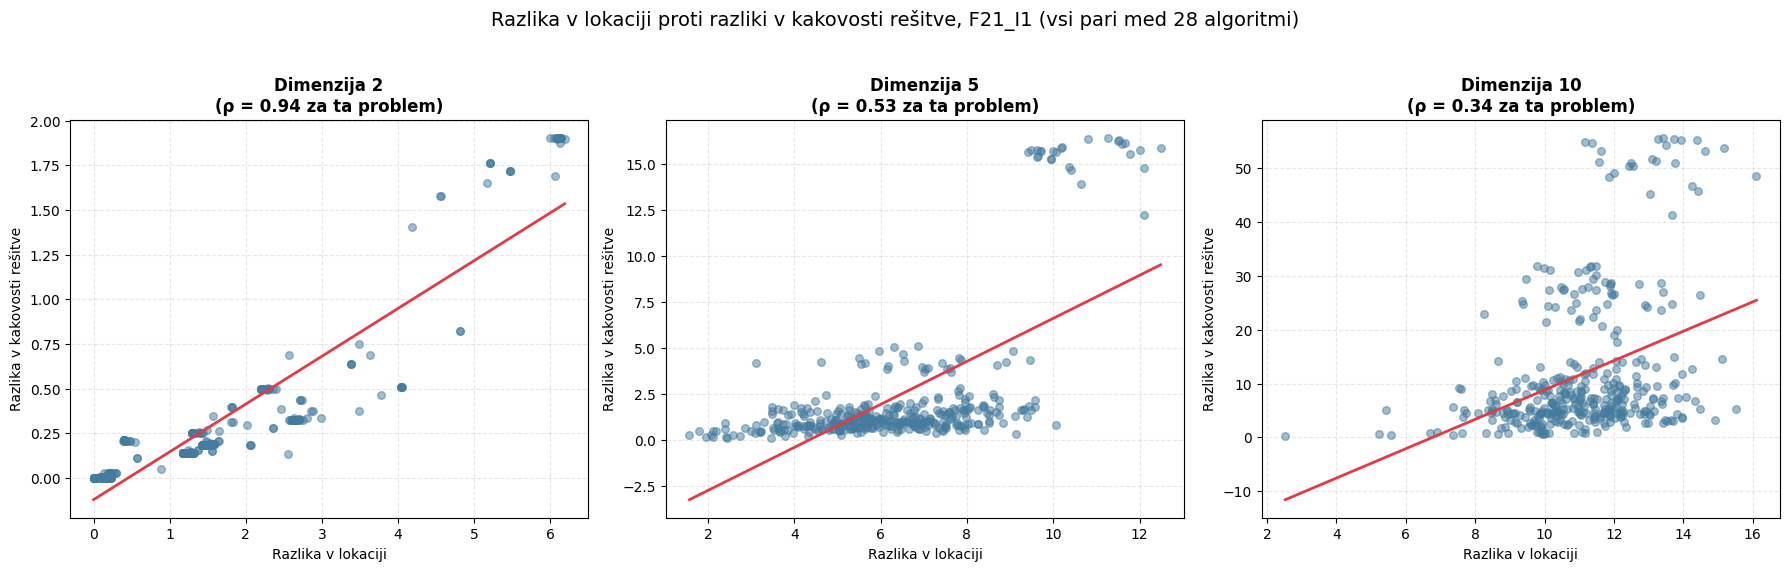

In [9]:
"""
Tripanelni scatter: razlika v lokaciji (x) proti razliki v fitnessu (y),
za vse pare med 28 algoritmi, na EDNEM problemu (F15_I1), ločeno po
dimenziji (2, 5, 10). Vsaka tocka je ena par algoritmov, povprecena cez
5 zagonov. Regresijska premica (OLS) in Spearmanova rho (izracunana samo
za ta problem, ne agregatno cez vse probleme) na vsakem panelu.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
# ---- nastavitve ----
F, I = 21, 1
DIMENSIONS = [2, 5, 10]
KEYS = ['Algorithm1', 'Algorithm2']
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, dim in zip(axes, DIMENSIONS):
    path = f'metrics_data/merged/merged_dim_{dim}.csv'
    if not os.path.isfile(path):
        ax.set_title(f'Dimenzija {dim}: manjka {path}')
        continue
    df = pd.read_csv(path)
    sub = df[(df['Function_id'] == F) & (df['Instance_id'] == I)]
    if sub.empty:
        ax.set_title(f'Dimenzija {dim}: ni podatkov za F{F}_I{I}')
        continue
    pair_means = sub.groupby(KEYS)[['location', 'fitness']].mean().reset_index()
    x = pair_means['location'].to_numpy()
    y = pair_means['fitness'].to_numpy()
    ax.scatter(x, y, alpha=0.5, s=30, color='#457b9d', zorder=3)
    # regresijska premica (OLS) na surovih vrednostih - smiselno, ker je to
    # en sam problem, torej sta obe meri na primerljivi skali
    if len(x) > 1 and np.std(x) > 0:
        slope, intercept, _, _, _ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='#e63946', linewidth=2, zorder=4)
    # Spearmanova rho SAMO za ta problem (lahko odstopa od agregatne
    # vrednosti cez vse probleme, navedene v besedilu sekcije)
    if len(x) > 2:
        rho, _ = stats.spearmanr(x, y)
        rho_label = f'ρ = {rho:.2f}'
    else:
        rho_label = 'premalo parov'
    ax.set_title(f'Dimenzija {dim}\n({rho_label} za ta problem)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Razlika v lokaciji')
    ax.set_ylabel('Razlika v kakovosti rešitve')
    ax.grid(True, linestyle='--', alpha=0.3)
fig.suptitle(f'Razlika v lokaciji proti razliki v kakovosti rešitve, F{F}_I{I} '
             f'(vsi pari med 28 algoritmi)', fontsize=14, y=1.03)
plt.tight_layout()
os.makedirs('figures_rezultati', exist_ok=True)
plt.savefig(f'figures_rezultati/lokacija_fitness_scatter_F{F}_I{I}.pdf', bbox_inches='tight')
plt.show()

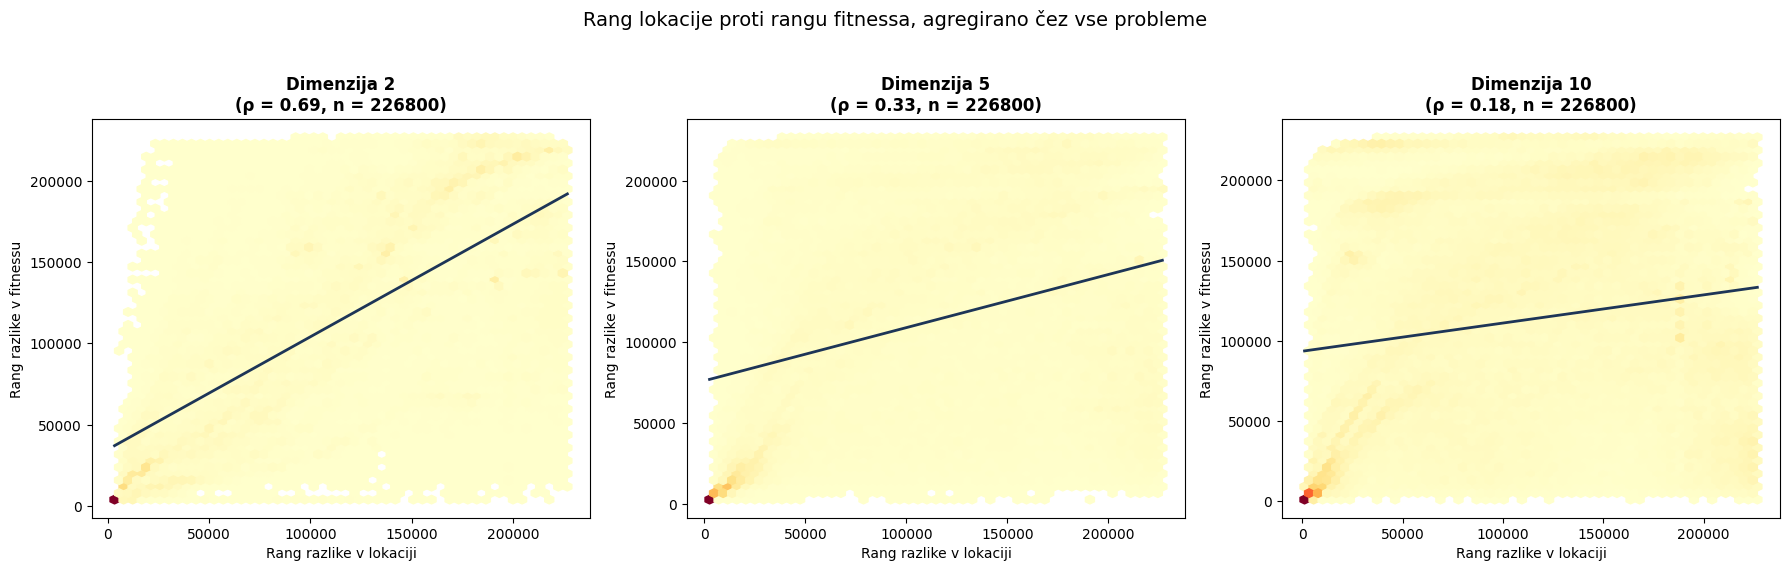

In [32]:
"""
Ilustracija Spearmanove korelacije lokacija<->fitness, AGREGIRANO cez vse
probleme (vse funkcije, instance, zagone) - torej isti podatki, ki so dali
agregatne vrednosti rho=0.69/0.33/0.18 v razdelku o dimenzijski odvisnosti.

Ker gre za ~227.000 vrstic na dimenzijo, uporabimo hexbin namesto
posameznih tock, in RANGE namesto surovih vrednosti (Spearman = Pearson na
rangih), da se izognemo mesanju skal med razlicnimi BBOB funkcijami.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

DIMENSIONS = [2, 5, 10]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, dim in zip(axes, DIMENSIONS):
    path = f'metrics_data/merged/merged_dim_{dim}.csv'
    if not os.path.isfile(path):
        ax.set_title(f'Dimenzija {dim}: manjka {path}')
        continue

    df = pd.read_csv(path)
    df = df.dropna(subset=['location', 'fitness'])

    # rangiraj OBE spremenljivki na CELOTNEM naboru te dimenzije - to je
    # natanko to, kar Spearman interno naredi
    x_rank = df['location'].rank()
    y_rank = df['fitness'].rank()

    hb = ax.hexbin(x_rank, y_rank, gridsize=50, cmap='YlOrRd', mincnt=1)

    # regresijska premica na rangih
    slope, intercept, _, _, _ = stats.linregress(x_rank, y_rank)
    x_line = np.linspace(x_rank.min(), x_rank.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='#1d3557', linewidth=2)

    rho, _ = stats.spearmanr(df['location'], df['fitness'])

    ax.set_title(f'Dimenzija {dim}\n(ρ = {rho:.2f}, n = {len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Rang razlike v lokaciji')
    ax.set_ylabel('Rang razlike v fitnessu')

fig.suptitle('Rang lokacije proti rangu fitnessa, agregirano čez vse probleme',
             fontsize=14, y=1.03)
plt.tight_layout()

os.makedirs('figures_rezultati', exist_ok=True)
plt.savefig('figures_rezultati/lokacija_fitness_rank_agregat.pdf', bbox_inches='tight')
plt.show()

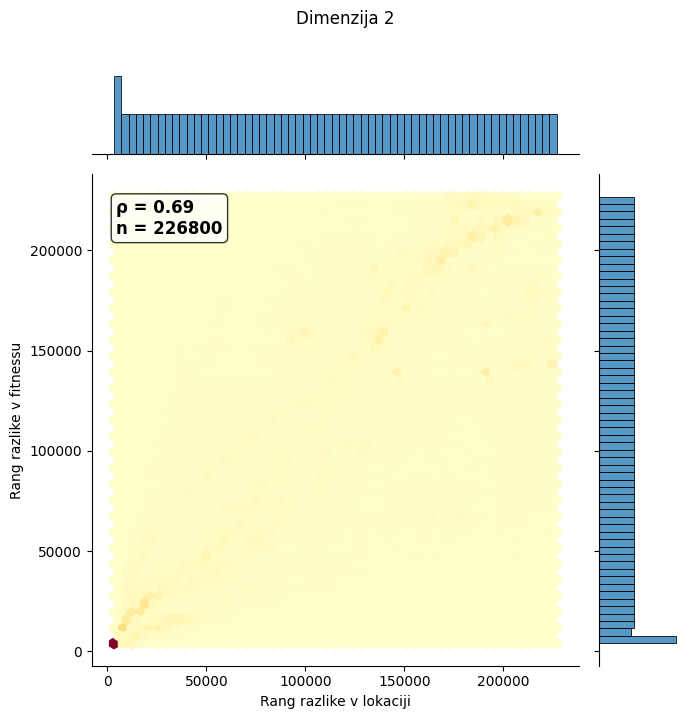

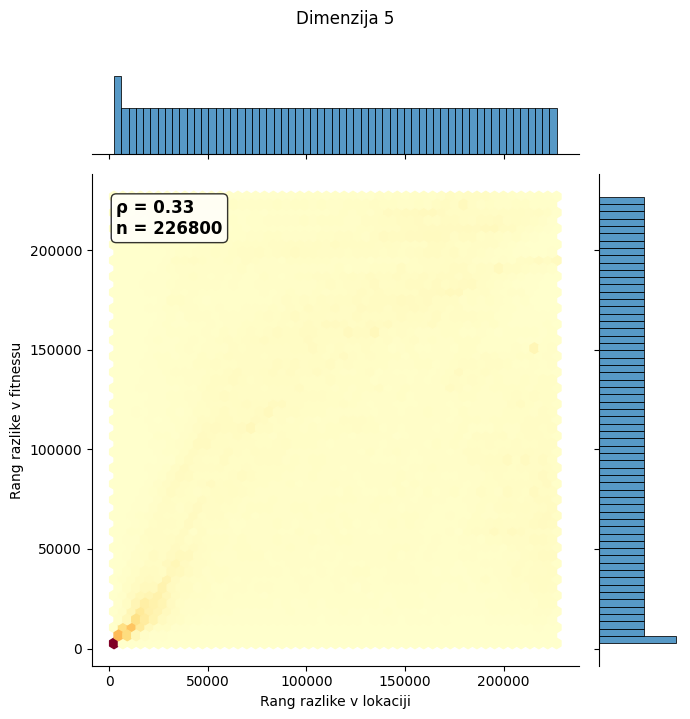

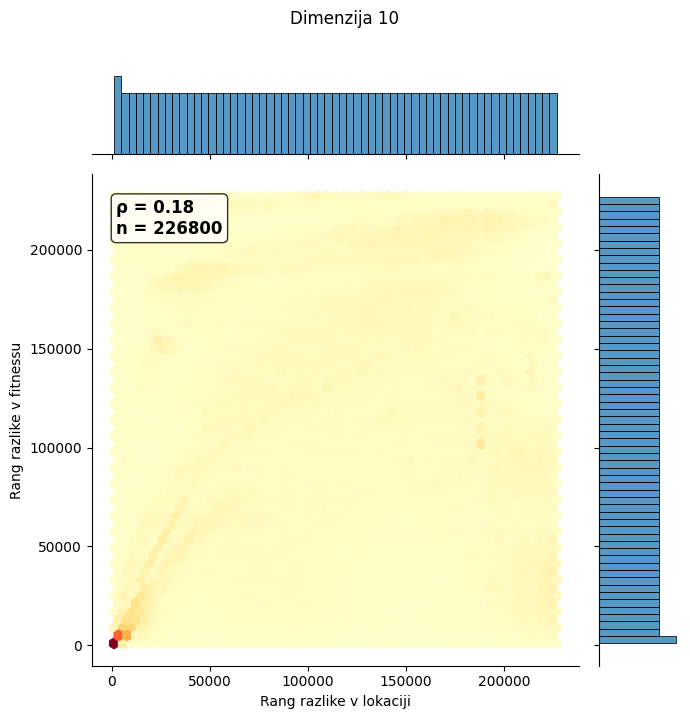

In [33]:
"""
sns.jointplot ilustracija Spearmanove korelacije lokacija<->fitness,
agregirano cez VSE probleme (isti podatki, ki dajo agregatne vrednosti
rho=0.69/0.33/0.18). Ena slika na dimenzijo (jointplot ustvari svojo
figuro, zato ne gre v en sam vecpanelni graf kot pri hexbin verziji).

Uporabimo range namesto surovih vrednosti - enak razlog kot prej: izognemo
se mesanju skal med razlicnimi BBOB funkcijami.
"""
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

DIMENSIONS = [2, 5, 10]
os.makedirs('figures_rezultati', exist_ok=True)

for dim in DIMENSIONS:
    path = f'metrics_data/merged/merged_dim_{dim}.csv'
    if not os.path.isfile(path):
        print(f'manjka {path}')
        continue

    df = pd.read_csv(path).dropna(subset=['location', 'fitness']).copy()

    # rangiraj obe spremenljivki - izognemo se mesanju skal med funkcijami
    df['location_rank'] = df['location'].rank()
    df['fitness_rank'] = df['fitness'].rank()

    rho, _ = stats.spearmanr(df['location'], df['fitness'])

    g = sns.jointplot(data=df, x='location_rank', y='fitness_rank',
                       kind='hex', height=7, cmap='YlOrRd')
    g.ax_joint.set_xlabel('Rang razlike v lokaciji')
    g.ax_joint.set_ylabel('Rang razlike v fitnessu')

    # anotacija Spearmanove rho neposredno na grafu
    g.ax_joint.annotate(f'ρ = {rho:.2f}\nn = {len(df)}',
                         xy=(0.05, 0.95), xycoords='axes fraction',
                         fontsize=12, fontweight='bold',
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    g.figure.suptitle(f'Dimenzija {dim}', y=1.02)
    plt.tight_layout()
    plt.savefig(f'figures_rezultati/jointplot_lokacija_fitness_dim{dim}.pdf', bbox_inches='tight')
    plt.show()